# k Vecinos más cercanos

In [24]:
# Importamos los módulos necesarios
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

# Generamos una función para visualizar los patrones en dos dimensiones
def plot2D(x1, x2, y, labels, caption):
  fig, ax = plt.subplots()
  for g in np.unique(y):
    i = np.where(y == g)[0]
    ax.scatter(x1[i], x2[i], color = labels[g], label = g)
  plt.xlabel("x")
  plt.ylabel("y")
  plt.title(caption)
  ax.legend()

## Ejemplo I

En este ejemplo, usamos un kernel lineal para clasificar un problema no linealmente separable. El resultado es una mala clasificación, no por un problema de la SVM, sino del kernel utilizado.

In [16]:
# Leemos los datos que usaremos
points =  pd.read_csv("https://raw.githubusercontent.com/jcobayliss/TC3002B-M2/refs/heads/main/datasets/centered.csv")

# Separamos las variables independientes de la dependiente
X = points.drop("Class", axis = 1)
y = points["Class"]

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.60, stratify = y, random_state = 54321)

# Creamos un modelo de clasificación usando el algoritmo de k-vecinos más cercanos
model = neighbors.KNeighborsClassifier(3, weights = "uniform")

# Entrenamos el modelo usando los datos de entrenamiento
model.fit(X_train, y_train)

# Realizamos la predicción usando los datos de prueba
prediction = model.predict(X_test)

# Generamos la matriz de confusión
confusion_matrix(y_test, prediction)

array([[88,  3],
       [ 6, 86]])

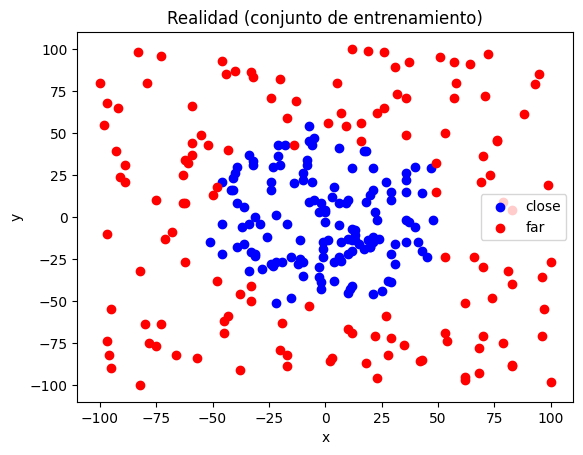

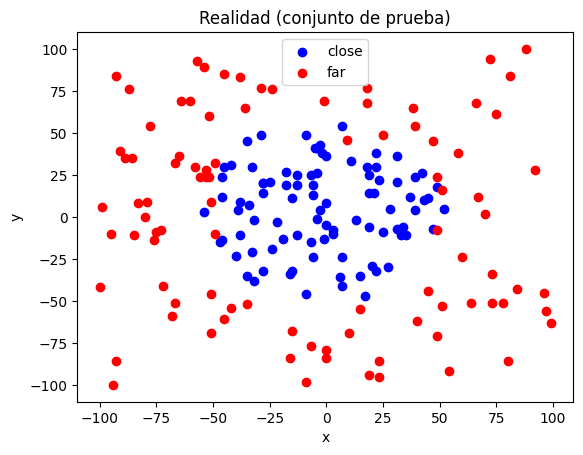

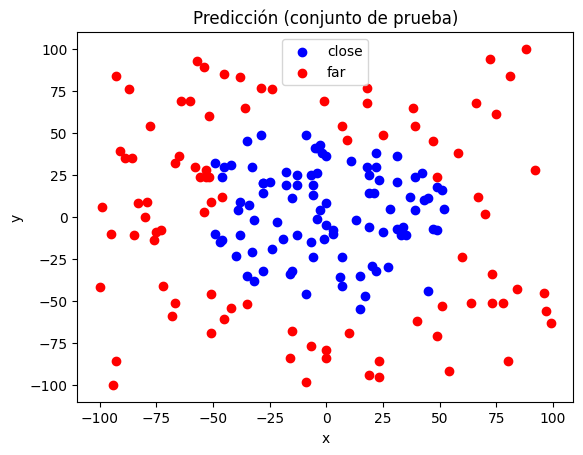

In [17]:
# Asociamos un color a cada etiqueta de la clase
labels = {"close": "blue", "far": "red"}

# Visualizamos el patrón 2D de la realidad en el conjunto de entrenamiento
x1 = X_train.iloc[:, 0].values
x2 = X_train.iloc[:, 1].values
y = y_train
plot2D(x1, x2, y, labels, "Realidad (conjunto de entrenamiento)")

# Visualizamos el patrón 2D de la realidad en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = y_test
plot2D(x1, x2, y, labels, "Realidad (conjunto de prueba)")

# Visualizamos el patrón 2D de la predicción en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = prediction
plot2D(x1, x2, y, labels, "Predicción (conjunto de prueba)")

## Ejemplo II

Es importante tener en cuanta que el algoritmo de $k$ vecinos más cercanos requiere que todas las variables independientes sean numéricas y en rangos similares. Esto nos obliga a escalar las variables para prevenir resultados incorrectos.

En este ejemplo, las variables independientes tienen rangos significativamente diferentes, provocando que el algoritmo sea incapaz de aprender correctamente el patrón en los datos.

In [18]:
# Leemos los datos que usaremos
points =  pd.read_csv("https://raw.githubusercontent.com/jcobayliss/TC3002B-M2/refs/heads/main/datasets/vertical.csv")

# Separamos las variables independientes de la dependiente
X = points.drop("Class", axis = 1)
y = points["Class"]

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.60, stratify = y, random_state = 54321)

# Creamos un modelo de clasificación usando el algoritmo de k-vecinos más cercanos
model = neighbors.KNeighborsClassifier(5, weights = "uniform")

# Entrenamos el modelo usando los datos de entrenamiento
model.fit(X_train, y_train)

# Realizamos la predicción usando los datos de prueba
prediction = model.predict(X_test)

# Generamos la matriz de confusión
confusion_matrix(y_test, prediction)

array([[30, 33],
       [33, 24]])

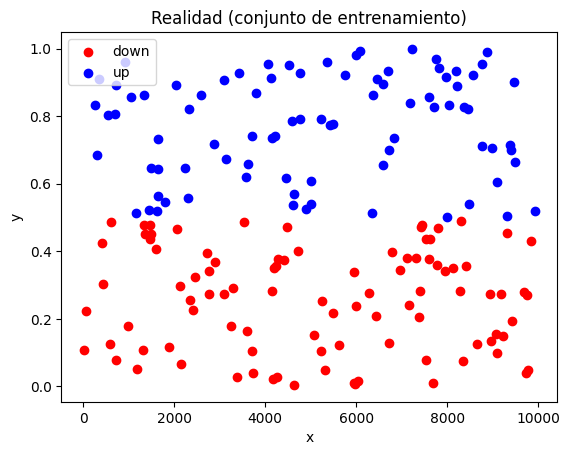

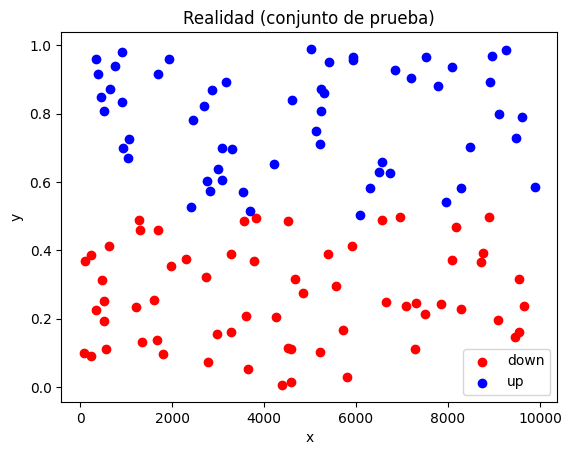

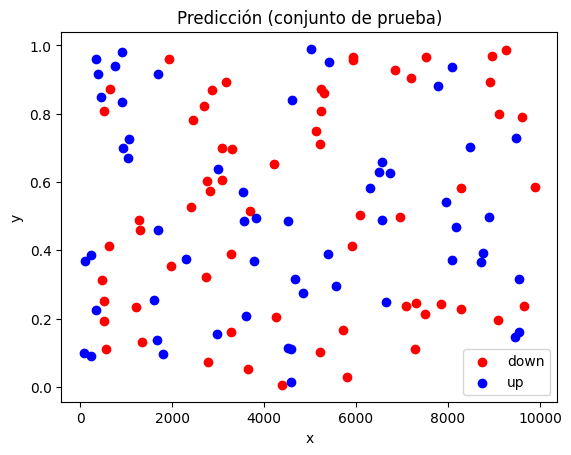

In [19]:
# Asociamos un color a cada etiqueta de la clase
labels = {"up": "blue", "down": "red"}

# Visualizamos el patrón 2D de la realidad en el conjunto de entrenamiento
x1 = X_train.iloc[:, 0].values
x2 = X_train.iloc[:, 1].values
y = y_train
plot2D(x1, x2, y, labels, "Realidad (conjunto de entrenamiento)")

# Visualizamos el patrón 2D de la realidad en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = y_test
plot2D(x1, x2, y, labels, "Realidad (conjunto de prueba)")

# Visualizamos el patrón 2D de la predicción en el conjunto de prueba
x1 = X_test.iloc[:, 0].values
x2 = X_test.iloc[:, 1].values
y = prediction
plot2D(x1, x2, y, labels, "Predicción (conjunto de prueba)")

## Ejemplo III

Para evitar el comportamiento errático observado en el ejemplo anterior, es indispensable escalar las variables antes de ejecutar el algoritmo de $k$ vecinos más cercanos.

In [20]:
# Leemos los datos que usaremos
points =  pd.read_csv("https://raw.githubusercontent.com/jcobayliss/TC3002B-M2/refs/heads/main/datasets/vertical.csv")

# Separamos las variables independientes de la dependiente
X = points.drop("Class", axis = 1)
y = points["Class"]

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.60, stratify = y, random_state = 54321)

# Creamos un escalador de datos
scaler = StandardScaler()

# Se ajusta el escalador usando únicamente los datos de entrenamiento
scaler.fit(X_train)

# Escalamos las variables independientes del entrenamiento y prueba
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Creamos un modelo de clasificación usando el algoritmo de k-vecinos más cercanosmodel = neighbors.KNeighborsClassifier(5, weights = "uniform")

# Entrenamos el modelo usando los datos de entrenamiento
model.fit(X_train, y_train)

# Realizamos la predicción usando los datos de prueba
prediction = model.predict(X_test)

# Generamos la matriz de confusión
confusion_matrix(y_test, prediction)

array([[60,  3],
       [ 1, 56]])

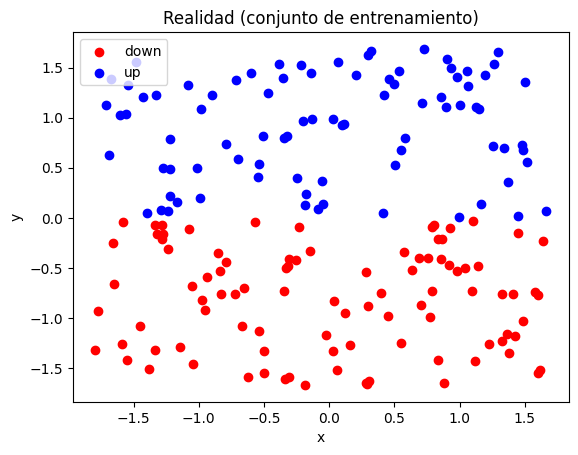

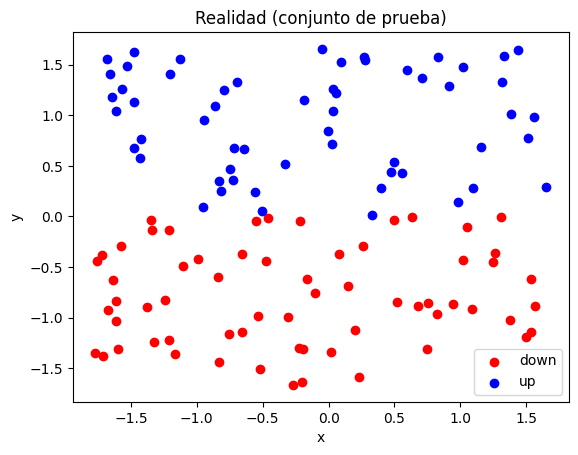

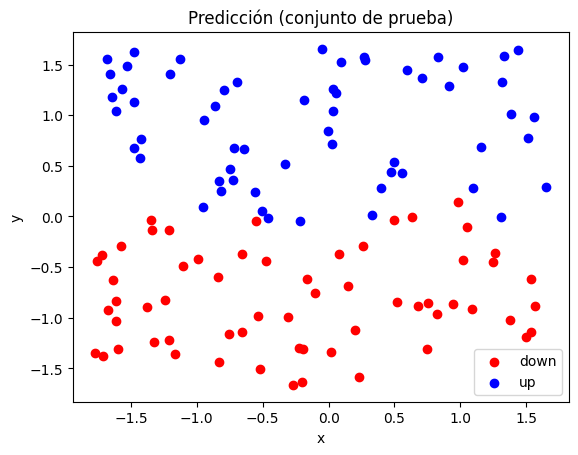

In [23]:
# Asociamos un color a cada etiqueta de la clase
labels = {"up": "blue", "down": "red"}

# Visualizamos el patrón 2D de la realidad en el conjunto de entrenamiento
x1 = X_train[:, 0]
x2 = X_train[:, 1]
y = y_train
plot2D(x1, x2, y, labels, "Realidad (conjunto de entrenamiento)")

# Visualizamos el patrón 2D de la realidad en el conjunto de prueba
x1 = X_test[:, 0]
x2 = X_test[:, 1]
y = y_test
plot2D(x1, x2, y, labels, "Realidad (conjunto de prueba)")

# Visualizamos el patrón 2D de la predicción en el conjunto de prueba
x1 = X_test[:, 0]
x2 = X_test[:, 1]
y = prediction
plot2D(x1, x2, y, labels, "Predicción (conjunto de prueba)")